In [1]:
# 忽略警告訊息
import warnings
warnings.filterwarnings("ignore")

# 匯入必要的套件
import matplotlib.pyplot as plt

# 使用 fivethirtyeight 風格，讓圖表更美觀
plt.style.use('fivethirtyeight')

# 設定字型，確保中文能正常顯示
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",
    "Microsoft YaHei",
    "SimHei",
    "Arial Unicode MS",
    "DejaVu Sans"
]

# 設定數學字型，確保負號能正常顯示
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

# Module 1：資料前處理

## 資料集欄位說明

| 欄位名稱 | 類型 | 說明 |
|---|---|---|
| `Number` | 數值型 | 寶可夢圖鑑編號。 |
| `Name` | 文字型 | 寶可夢名稱。 |
| `Type1` | 類別型 | 第一屬性，例如 Grass、Fire、Water。 |
| `Type2` | 類別型 / 遺漏值 | 第二屬性；若沒有第二屬性，會是遺漏值。 |
| `HP` | 數值型 | 生命值能力。 |
| `Attack` | 數值型 | 物理攻擊能力。 |
| `Defense` | 數值型 | 物理防禦能力。 |
| `SpecialAtk` | 數值型 | 特殊攻擊能力。 |
| `SpecialDef` | 數值型 | 特殊防禦能力。 |
| `Speed` | 數值型 | 速度能力。 |
| `Generation` | 有序 / 數值型 | 寶可夢世代。 |
| `Legendary` | 目標標記 | 是否為傳說寶可夢。 |

本章常用的數值特徵順序固定為：

`HP`, `Attack`, `Defense`, `SpecialAtk`, `SpecialDef`, `Speed`


## 1. 讀取資料與初步檢視

本教材只在這一格讀取資料。後面所有章節都從 `data.copy()` 複製資料使用，避免反覆讀取檔案，也比較容易追蹤資料來源。


In [2]:
# ============================================================
# 1. 讀取資料與初步檢視
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 只在一開始讀取一次資料
# 後續章節都會從 data.copy() 複製資料使用
# 這樣可以確保所有處理都來自同一份原始資料
data = pd.read_csv("./ex1.csv")

# 固定本章常用的數值特徵順序
numeric_features = ["HP", "Attack", "Defense", "SpecialAtk", "SpecialDef", "Speed"]

# 固定本章常用的類別特徵
categorical_features = ["Type1", "Type2", "Generation"]

# 檢視前 5 筆資料
print("前 5 筆資料：")
display(data.head())

# 檢視資料筆數與欄位數
print("資料筆數與欄位數：")
print(data.shape)

# 檢視欄位型態、非空值數量、記憶體使用量
# 這一格可以幫助我們知道哪些欄位有遺漏值，以及哪些欄位是數值型或類別型
print("資料基本資訊：")
display(data.info())

前 5 筆資料：


,Number,Name,Type1,Type2,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed,Generation,Legendary
0,1,妙蛙種子,Grass,Poison,45.0,49,49,65,65,45,1,False
1,2,妙蛙草,Grass,Poison,60.0,62,63,80,80,60,1,False
2,3,妙蛙花,Grass,Poison,80.0,82,83,100,100,80,1,False
3,3,妙蛙花Mega,Grass,Poison,80.0,100,123,122,120,80,1,False
4,4,小火龍,Fire,NaN,39.0,52,43,60,50,65,1,False


資料筆數與欄位數：
(168, 12)
資料基本資訊：
<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Number      168 non-null    int64  
 1   Name        168 non-null    str    
 2   Type1       168 non-null    str    
 3   Type2       79 non-null     str    
 4   HP          166 non-null    float64
 5   Attack      168 non-null    int64  
 6   Defense     168 non-null    int64  
 7   SpecialAtk  168 non-null    int64  
 8   SpecialDef  168 non-null    int64  
 9   Speed       168 non-null    int64  
 10  Generation  168 non-null    int64  
 11  Legendary   168 non-null    bool   
dtypes: bool(1), float64(1), int64(7), str(3)
memory usage: 14.7 KB


None

## 2. 數值型資料：標準化與正規化

這一節示範 Module 1 提到的四種常見數值轉換方式：

1. `StandardScaler`：讓每個特徵平均值接近 0、標準差接近 1。
2. `MinMaxScaler`：把每個特徵縮放到指定範圍，常見是 0 到 1。
3. `RobustScaler`：使用中位數與四分位距，對離群值比較穩健。
4. `Normalizer`：不是針對欄位，而是針對每一筆樣本向量，讓樣本向量長度變成 1。

注意：本資料的 `HP` 有少量遺漏值。為了先示範縮放概念，這裡先使用 `dropna()` 暫時移除有遺漏值的列；正式的遺漏值填補會在下一節說明。


In [3]:
# ============================================================
# 2. 數值型資料：StandardScaler、MinMaxScaler、RobustScaler、Normalizer
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import Normalizer

# 從原始資料中選取數值型特徵，並複製一份新的 DataFrame 來處理
numeric_data = data.loc[:, numeric_features].copy()

# 為了讓各種 scaler 可以順利執行，先暫時移除有遺漏值的資料列
numeric_data_without_missing = numeric_data.dropna(axis=0).copy()

print("原始數值資料：")
display(numeric_data_without_missing.head())

# ------------------------------------------------------------
# StandardScaler：每個特徵平均值約為 0，標準差約為 1
# ------------------------------------------------------------
standard_scaler = StandardScaler()
standard_scaled = standard_scaler.fit_transform(numeric_data_without_missing)
standard_scaled = pd.DataFrame(standard_scaled, columns=numeric_features)

print("StandardScaler 結果：")
display(standard_scaled.head())

# ------------------------------------------------------------
# MinMaxScaler：每個特徵縮放到 0 到 1
# ------------------------------------------------------------
minmax_scaler = MinMaxScaler()
minmax_scaled = minmax_scaler.fit_transform(numeric_data_without_missing)
minmax_scaled = pd.DataFrame(minmax_scaled, columns=numeric_features)

print("MinMaxScaler 結果：")
display(minmax_scaled.head())

# ------------------------------------------------------------
# RobustScaler：使用中位數與四分位距，對離群值比較穩健
# ------------------------------------------------------------
robust_scaler = RobustScaler()
robust_scaled = robust_scaler.fit_transform(numeric_data_without_missing)
robust_scaled = pd.DataFrame(robust_scaled, columns=numeric_features)

print("RobustScaler 結果：")
display(robust_scaled.head())

# ------------------------------------------------------------
# Normalizer：針對每一筆樣本向量做正規化
# ------------------------------------------------------------
normalizer = Normalizer(norm="l2")
normalized = normalizer.fit_transform(numeric_data_without_missing)
normalized = pd.DataFrame(normalized, columns=numeric_features)

print("Normalizer 結果：")
display(normalized.head())

原始數值資料：


,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed
0,45.0,49,49,65,65,45
1,60.0,62,63,80,80,60
2,80.0,82,83,100,100,80
3,80.0,100,123,122,120,80
4,39.0,52,43,60,50,65


StandardScaler 結果：


,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed
0,-0.741717,-0.901689,-0.765593,-0.198609,-0.160858,-0.932334
1,-0.207320,-0.477573,-0.275310,0.238260,0.429035,-0.425343
2,0.505209,0.174914,0.425095,0.820753,1.215559,0.250645
3,0.505209,0.762151,1.825903,1.461494,2.002083,0.250645
4,-0.955475,-0.803816,-0.975714,-0.344232,-0.750752,-0.256346


MinMaxScaler 結果：


,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed
0,0.145833,0.237838,0.251429,0.279330,0.409091,0.222222
1,0.208333,0.308108,0.331429,0.363128,0.545455,0.333333
2,0.291667,0.416216,0.445714,0.474860,0.727273,0.481481
3,0.291667,0.513514,0.674286,0.597765,0.909091,0.481481
4,0.120833,0.254054,0.217143,0.251397,0.272727,0.370370


RobustScaler 結果：


,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed
0,-0.507463,-0.650,-0.485714,0.00,-0.142857,-0.591716
1,-0.059701,-0.325,-0.085714,0.30,0.285714,-0.236686
2,0.537313,0.175,0.485714,0.70,0.857143,0.236686
3,0.537313,0.625,1.628571,1.14,1.428571,0.236686
4,-0.686567,-0.575,-0.657143,-0.10,-0.571429,-0.118343


Normalizer 結果：


,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed
0,0.342109,0.372519,0.372519,0.494157,0.494157,0.342109
1,0.359772,0.371764,0.377761,0.479696,0.479696,0.359772
2,0.371339,0.380622,0.385264,0.464173,0.464173,0.371339
3,0.308577,0.385721,0.474437,0.470580,0.462865,0.308577
4,0.304548,0.406064,0.335784,0.468536,0.390446,0.507580


## 3. 類別型資料：名目特徵、有序特徵與編碼

類別型資料不能直接丟進大部分機器學習模型，所以需要先轉換成數值形式。

這一節示範：

1. 名目特徵：`Type1`，不同屬性之間沒有大小順序。
2. 有序特徵：`Generation`，世代具有自然順序。
3. 獨熱編碼：使用 `pd.get_dummies()` 把類別欄位轉成 0 / 1 欄位。
4. `LabelBinarizer`：適合把二元或多類別目標標記轉成二元形式。
5. `LabelEncoder`：適合把目標標記轉成整數；不建議直接用在沒有順序的輸入特徵上，避免模型誤以為數字大小有意義。


In [4]:
# ============================================================
# 3. 類別型資料：One-hot Encoding、LabelBinarizer、LabelEncoder
# ============================================================

from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import LabelEncoder

category_data = data.copy()

# ------------------------------------------------------------
# 名目特徵：Type1 沒有大小順序
# ------------------------------------------------------------
print("Type1 的前幾筆資料：")
display(category_data.loc[:, ["Name", "Type1"]].head())

# ------------------------------------------------------------
# 有序特徵：Generation 可以保留成數字，因為世代本身有順序
# ------------------------------------------------------------
generation_data = category_data.loc[:, ["Name", "Generation"]].copy()
print("有序特徵 Generation：")
display(generation_data.head())

# ------------------------------------------------------------
# 獨熱編碼：適合處理沒有順序的類別型特徵
# ------------------------------------------------------------
type1_one_hot = pd.get_dummies(category_data["Type1"], prefix="Type1", dtype=int)
print("Type1 獨熱編碼結果：")
display(type1_one_hot.head())

# ------------------------------------------------------------
# Optional: 獨熱編碼：使用 sklearn 的 OneHotEncoder
# ------------------------------------------------------------
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder()

encoder.fit(category_data[['Type1']])
'''
encoder.fit 需要寫成 encoder = encoder.fit 嗎？
不需要，因為 encoder.fit 會直接修改 encoder 物件本身，並不會回傳一個新的物件。
'''
X_train_encoded = encoder.transform(category_data[['Type1']])
# 也可以寫成 X_train_encoded = encoder.fit_transform(category_data[['Type1']])

# 還原成原始類別型資料
X_train_origin = encoder.inverse_transform(X_train_encoded)

# 轉換後的特徵名稱
features = encoder.get_feature_names_out(['Type1'])
print("轉換後的特徵名稱:")
print(features)

# 前 3 筆還原成原始類別型資料
print("前 3 筆還原成原始類別型資料:")
print(X_train_origin[:3])

# 前 3 筆轉換成 one-hot encoding 的資料
print("前 3 筆轉換成 one-hot encoding 的資料:")
print(X_train_encoded[:3].toarray())

# ------------------------------------------------------------
# LabelBinarizer：常用於目標 y 的二元化
# ------------------------------------------------------------
label_binarizer = LabelBinarizer()
legendary_binary = label_binarizer.fit_transform(category_data["Legendary"])
legendary_binary = pd.DataFrame(legendary_binary, columns=["Legendary_binary"])
print("LabelBinarizer 將 Legendary 轉成 0 / 1：")
display(legendary_binary.head())

# ------------------------------------------------------------
# LabelEncoder：常用於目標 y 的整數化
# 這裡示範 Type1 會被轉成整數，但要提醒：
# Type1 本身沒有大小順序，因此不建議直接把這個結果當成輸入特徵 X。
# ------------------------------------------------------------
label_encoder = LabelEncoder()
type1_label = label_encoder.fit_transform(category_data["Type1"])
type1_label = pd.DataFrame({"Type1": category_data["Type1"], "Type1_label": type1_label})
print("LabelEncoder 示範結果：")
display(type1_label.head())

Type1 的前幾筆資料：


,Name,Type1
0,妙蛙種子,Grass
1,妙蛙草,Grass
2,妙蛙花,Grass
3,妙蛙花Mega,Grass
4,小火龍,Fire


有序特徵 Generation：


,Name,Generation
0,妙蛙種子,1
1,妙蛙草,1
2,妙蛙花,1
3,妙蛙花Mega,1
4,小火龍,1


Type1 獨熱編碼結果：


,Type1_Bug,Type1_Dragon,Type1_Electric,Type1_Fairy,Type1_Fighting,Type1_Fire,Type1_Ghost,Type1_Grass,Type1_Ground,Type1_Ice,Type1_Normal,Type1_Poison,Type1_Psychic,Type1_Rock,Type1_Water
0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


轉換後的特徵名稱:
['Type1_Bug' 'Type1_Dragon' 'Type1_Electric' 'Type1_Fairy'
 'Type1_Fighting' 'Type1_Fire' 'Type1_Ghost' 'Type1_Grass' 'Type1_Ground'
 'Type1_Ice' 'Type1_Normal' 'Type1_Poison' 'Type1_Psychic' 'Type1_Rock'
 'Type1_Water']
前 3 筆還原成原始類別型資料:
[['Grass']
 ['Grass']
 ['Grass']]
前 3 筆轉換成 one-hot encoding 的資料:
[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]]
LabelBinarizer 將 Legendary 轉成 0 / 1：


,Legendary_binary
0,0
1,0
2,0
3,0
4,0


LabelEncoder 示範結果：


,Type1,Type1_label
0,Grass,7
1,Grass,7
2,Grass,7
3,Grass,7
4,Fire,5


## 4. 遺漏值處理：SimpleImputer 與 KNNImputer

真實資料常常會有空值或缺失值。若不處理，許多機器學習模型會無法訓練。

這一節示範：

1. `SimpleImputer`：用平均值、中位數、最常出現值或固定常數填補。
2. `KNNImputer`：用相似樣本的鄰近資料推估缺失值。

在本資料中，`HP` 有少量遺漏值，`Type2` 則有較多空值，因為很多寶可夢沒有第二屬性。


In [5]:
# ============================================================
# 4. 遺漏值處理：SimpleImputer 與 KNNImputer
# ============================================================

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer

missing_data = data.copy()

print("每個欄位的遺漏值數量：")
display(missing_data.isna().sum())

# ------------------------------------------------------------
# SimpleImputer：用中位數填補數值欄位
# ------------------------------------------------------------
numeric_missing_data = missing_data.loc[:, numeric_features].copy()

simple_imputer = SimpleImputer(strategy="median")
simple_imputed = simple_imputer.fit_transform(numeric_missing_data)
simple_imputed = pd.DataFrame(simple_imputed, columns=numeric_features)

print("SimpleImputer 填補後的數值資料：")
display(simple_imputed.head())

# ------------------------------------------------------------
# SimpleImputer：用固定文字填補 Type2
# 這裡的意思是：沒有第二屬性就填成 NoType2
# ------------------------------------------------------------
type2_imputer = SimpleImputer(strategy="constant", fill_value="NoType2")
type2_imputed = type2_imputer.fit_transform(missing_data.loc[:, ["Type2"]])
type2_imputed = pd.DataFrame(type2_imputed, columns=["Type2_imputed"])

print("Type2 填補後的結果：")
display(type2_imputed.head(10))

# ------------------------------------------------------------
# KNNImputer：根據相似樣本填補數值欄位
# ------------------------------------------------------------
knn_imputer = KNNImputer(n_neighbors=3)
knn_imputed = knn_imputer.fit_transform(numeric_missing_data)
knn_imputed = pd.DataFrame(knn_imputed, columns=numeric_features)

print("KNNImputer 填補後的數值資料：")
display(knn_imputed.head())

print("原本 HP 遺漏的列，填補後的比較：")
missing_hp_rows = missing_data["HP"].isna()
comparison = pd.DataFrame({
    "Name": missing_data.loc[missing_hp_rows, "Name"],
    "Original_HP": missing_data.loc[missing_hp_rows, "HP"],
    "SimpleImputer_HP": simple_imputed.loc[missing_hp_rows, "HP"],
    "KNNImputer_HP": knn_imputed.loc[missing_hp_rows, "HP"]
}).reset_index(drop=True)
display(comparison)

每個欄位的遺漏值數量：


Number         0
Name           0
Type1          0
Type2         89
HP             2
Attack         0
Defense        0
SpecialAtk     0
SpecialDef     0
Speed          0
Generation     0
Legendary      0
dtype: int64

SimpleImputer 填補後的數值資料：


,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed
0,45.0,49.0,49.0,65.0,65.0,45.0
1,60.0,62.0,63.0,80.0,80.0,60.0
2,80.0,82.0,83.0,100.0,100.0,80.0
3,80.0,100.0,123.0,122.0,120.0,80.0
4,39.0,52.0,43.0,60.0,50.0,65.0


Type2 填補後的結果：


,Type2_imputed
0,Poison
1,Poison
2,Poison
3,Poison
4,NoType2
5,NoType2
6,Flying
7,Dragon
8,Flying
9,NoType2


KNNImputer 填補後的數值資料：


,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed
0,45.0,49.0,49.0,65.0,65.0,45.0
1,60.0,62.0,63.0,80.0,80.0,60.0
2,80.0,82.0,83.0,100.0,100.0,80.0
3,80.0,100.0,123.0,122.0,120.0,80.0
4,39.0,52.0,43.0,60.0,50.0,65.0


原本 HP 遺漏的列，填補後的比較：


,Name,Original_HP,SimpleImputer_HP,KNNImputer_HP
0,月桂葉,NaN,62.0,69.666667
1,安瓢蟲,NaN,62.0,60.000000


## 5. 切割資料集與 K-fold Cross Validation

這一節示範兩件事：

1. `train_test_split`：把資料切成訓練資料與測試資料。
2. K-fold cross validation：把資料分成多份，輪流訓練與驗證。

注意：這裡使用 `KNeighborsClassifier` 只是為了示範「每一 fold 都會重新訓練模型並得到分數」。模型原理會在後續分類章節再正式說明。


In [6]:
# ============================================================
# 5. 切割資料集與 K-fold Cross Validation
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 從原始資料複製一份新的 DataFrame 來處理，確保所有處理都來自同一份原始資料
split_data = data.copy()

# 選取數值特徵作為輸入 X，類別特徵 Legendary 作為目標 y
X = split_data.loc[:, numeric_features].copy()
y = split_data["Legendary"].astype(int).copy()

# 先處理遺漏值
split_imputer = SimpleImputer(strategy="median")
X_filled = split_imputer.fit_transform(X)

# ------------------------------------------------------------
# train_test_split：切成訓練資料與測試資料
# stratify=y 可以讓訓練集與測試集的類別比例比較接近
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_filled,
    y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

# KNN 是距離導向模型，因此這裡先標準化
# 注意：scaler 只能 fit 在訓練資料，不能偷看測試資料
split_scaler = StandardScaler()
X_train_scaled = split_scaler.fit_transform(X_train)
X_test_scaled = split_scaler.transform(X_test)

split_model = KNeighborsClassifier(n_neighbors=3)
split_model.fit(X_train_scaled, y_train)

print("train_test_split 結果：")
print("訓練資料分數：", split_model.score(X_train_scaled, y_train))
print("測試資料分數：", split_model.score(X_test_scaled, y_test))

# ------------------------------------------------------------
# K-fold Cross Validation：檢視每一個 fold 的訓練結果
# ------------------------------------------------------------
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=0)
fold_results = []
fold_number = 1

# 每一個 fold 都要從原始資料重新切割訓練集與驗證集，保證每一個 fold 的資料處理都是獨立的
for train_index, valid_index in cv.split(X_filled, y):
    # 將原始資料切割成訓練集與驗證集
    X_fold_train = X_filled[train_index]
    X_fold_valid = X_filled[valid_index]
    y_fold_train = y.iloc[train_index]
    y_fold_valid = y.iloc[valid_index]

    # 每一個 fold 都要重新 fit scaler，保證沒有偷看驗證資料
    fold_scaler = StandardScaler()
    X_fold_train_scaled = fold_scaler.fit_transform(X_fold_train)
    X_fold_valid_scaled = fold_scaler.transform(X_fold_valid)

    # 每一個 fold 都要重新 fit 模型，保證每一個 fold 的訓練都是獨立的
    fold_model = KNeighborsClassifier(n_neighbors=3)
    fold_model.fit(X_fold_train_scaled, y_fold_train)

    # 計算訓練分數與驗證分數
    train_score = fold_model.score(X_fold_train_scaled, y_fold_train)
    valid_score = fold_model.score(X_fold_valid_scaled, y_fold_valid)

    # 記錄每一個 fold 的結果
    fold_results.append({
        "fold": fold_number,
        "train_size": len(train_index),
        "valid_size": len(valid_index),
        "train_score": train_score,
        "valid_score": valid_score
    })

    # 下一個 fold 的編號
    fold_number = fold_number + 1

fold_results = pd.DataFrame(fold_results)
print("每一個 fold 的訓練與驗證結果：")
display(fold_results)

train_test_split 結果：
訓練資料分數： 0.9761904761904762
測試資料分數： 1.0
每一個 fold 的訓練與驗證結果：


,fold,train_size,valid_size,train_score,valid_score
0,1,112,56,0.973214,0.964286
1,2,112,56,0.982143,0.946429
2,3,112,56,0.991071,0.982143


## 6. 異常值偵測：Elliptic Envelope、IQR、Isolation Forest、LOF

這一節示範四種離群值偵測方法：

1. `EllipticEnvelope`：適合資料大致接近高斯分布的情況。
2. IQR method：使用四分位距判斷一維特徵的離群值。
3. `IsolationForest`：透過隨機切割資料，找出容易被隔離的樣本。
4. `LocalOutlierFactor`：比較樣本與鄰居的局部密度差異。

scikit-learn 的許多異常偵測方法會回傳：

- `1`：正常值
- `-1`：離群值


In [7]:
# ============================================================
# 6. 異常值偵測：Elliptic Envelope、IQR、Isolation Forest、LOF
# ============================================================

from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

outlier_data = data.copy()

# 先準備數值特徵，並填補遺漏值
outlier_imputer = SimpleImputer(strategy="median")
X_outlier = outlier_imputer.fit_transform(outlier_data.loc[:, numeric_features].values)

# 多數距離或邊界方法對尺度敏感，因此先標準化
outlier_scaler = StandardScaler()
X_outlier_scaled = outlier_scaler.fit_transform(X_outlier)

# 為了方便比較各種方法的結果，先把 Name 與數值特徵複製到 outlier_result DataFrame
outlier_result = outlier_data.loc[:, ["Name"] + numeric_features].copy()

# ------------------------------------------------------------
# 1. Elliptic Envelope
# ------------------------------------------------------------
elliptic_model = EllipticEnvelope(contamination=0.05, random_state=0)
outlier_result["EllipticEnvelope"] = elliptic_model.fit_predict(X_outlier_scaled)

# ------------------------------------------------------------
# 2. IQR method：這裡用 HP 當作一維示範
# ------------------------------------------------------------
hp_series = outlier_result["HP"].copy()

# 計算 HP 的第一四分位數
hp_q1 = hp_series.quantile(0.25)

# 計算 HP 的第三四分位數
hp_q3 = hp_series.quantile(0.75)

# 計算 HP 的四分位距
hp_iqr = hp_q3 - hp_q1

# 計算 HP 的下界與上界
hp_lower_bound = hp_q1 - 1.5 * hp_iqr

# 計算 HP 的上界
hp_upper_bound = hp_q3 + 1.5 * hp_iqr

# 預設先把 IQR_HP 欄位填成 1，代表非離群值
outlier_result["IQR_HP"] = 1

# 根據下界與上界判定離群值，離群值標記為 -1，非離群值保持 1
outlier_result.loc[outlier_result["HP"] < hp_lower_bound, "IQR_HP"] = -1
outlier_result.loc[outlier_result["HP"] > hp_upper_bound, "IQR_HP"] = -1

# ------------------------------------------------------------
# 3. Isolation Forest
# ------------------------------------------------------------
isolation_model = IsolationForest(contamination=0.05, random_state=0)
outlier_result["IsolationForest"] = isolation_model.fit_predict(X_outlier_scaled)

# ------------------------------------------------------------
# 4. Local Outlier Factor
# ------------------------------------------------------------
lof_model = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outlier_result["LOF"] = lof_model.fit_predict(X_outlier_scaled)
outlier_result["LOF_negative_score"] = lof_model.negative_outlier_factor_

print("各方法偵測到的離群值數量：")
summary = pd.DataFrame()
summary["method"] = ["EllipticEnvelope", "IQR_HP", "IsolationForest", "LOF"]
summary["outlier_count"] = [
    (outlier_result["EllipticEnvelope"] == -1).sum(),
    (outlier_result["IQR_HP"] == -1).sum(),
    (outlier_result["IsolationForest"] == -1).sum(),
    (outlier_result["LOF"] == -1).sum()
]
display(summary)

print("被任一方法判定為離群值的資料：")
any_outlier = (
    (outlier_result["EllipticEnvelope"] == -1) |
    (outlier_result["IQR_HP"] == -1) |
    (outlier_result["IsolationForest"] == -1) |
    (outlier_result["LOF"] == -1)
)
# print(any_outlier.to_numpy())
display(outlier_result.loc[any_outlier].head(20))

各方法偵測到的離群值數量：


,method,outlier_count
0,EllipticEnvelope,9
1,IQR_HP,3
2,IsolationForest,9
3,LOF,9


被任一方法判定為離群值的資料：


,Name,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed,EllipticEnvelope,IQR_HP,IsolationForest,LOF,LOF_negative_score
19,大針蜂Mega,65.0,150,40,15,80,145,1,1,-1,-1,-1.770435
44,胖丁,115.0,45,20,45,25,20,-1,1,-1,-1,-1.804923
45,胖可丁,140.0,70,45,85,50,45,-1,-1,1,-1,-1.592939
71,胡地Mega,55.0,50,65,175,95,150,1,1,-1,-1,-1.522397
87,呆殼獸Mega,95.0,75,180,130,80,30,-1,1,-1,-1,-1.732665
97,大舌貝,30.0,65,100,45,25,40,-1,1,1,1,-1.276313
98,刺甲貝,50.0,95,180,85,45,70,-1,1,-1,1,-1.490391
103,大岩蛇,35.0,45,160,30,45,70,-1,1,1,1,-1.486352
107,巨鉗蟹,55.0,130,115,50,50,75,-1,1,1,1,-1.231413
121,吉利蛋,250.0,5,5,35,105,50,-1,-1,-1,-1,-3.601411


### 異常值視覺化

下面用 `matplotlib` 畫出 `HP` 和 `Attack` 的散點圖，並用 `IsolationForest` 的結果標示哪些樣本可能是離群值。


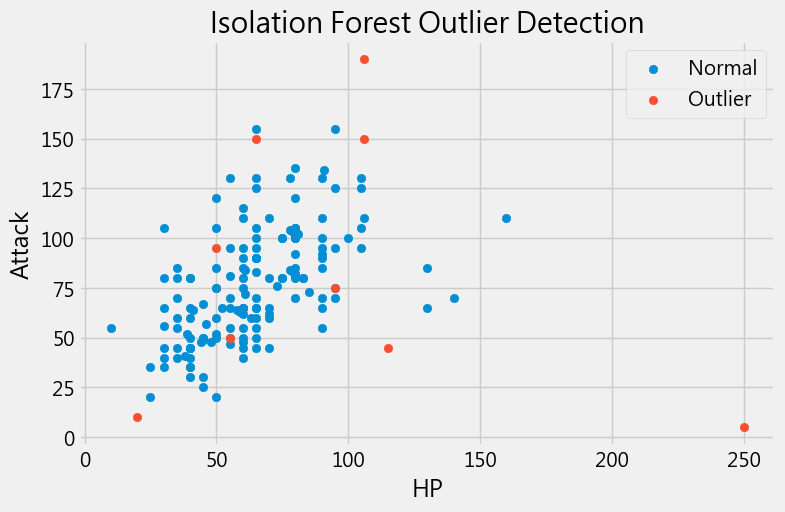

In [8]:
# ============================================================
# 6. 異常值視覺化：使用 matplotlib
# ============================================================

normal_points = outlier_result["IsolationForest"] == 1
outlier_points = outlier_result["IsolationForest"] == -1

plt.figure(figsize=(8, 5))

plt.scatter(
    outlier_result.loc[normal_points, "HP"],
    outlier_result.loc[normal_points, "Attack"],
    label="Normal"
)

plt.scatter(
    outlier_result.loc[outlier_points, "HP"],
    outlier_result.loc[outlier_points, "Attack"],
    label="Outlier"
)

plt.xlabel("HP")
plt.ylabel("Attack")
plt.title("Isolation Forest Outlier Detection")
plt.legend()
plt.grid(True)
plt.show()

## 7. 處理離群值與偵測新奇值

離群值不一定都要刪除。Module 1 提到三種常見處理方向：

1. 直接刪除偵測到的離群值。
2. 新增一個欄位標示離群值，保留原始資料。
3. 轉換特徵值，例如對偏態很大的欄位做 `log1p` 轉換。

接著示範 novelty detection。新奇值偵測的重點是：先用「已知正常資料」訓練，再判斷新進資料是否異常。


In [9]:
# ============================================================
# 7. 處理離群值與偵測新奇值
# ============================================================

from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

handling_data = data.copy()

# ------------------------------------------------------------
# 方法 1：刪除 IsolationForest 判定的離群值
# ------------------------------------------------------------
clean_data = handling_data.loc[outlier_result["IsolationForest"] == 1].copy()
print("刪除離群值前的資料筆數：", handling_data.shape[0])
print("刪除離群值後的資料筆數：", clean_data.shape[0])

# ------------------------------------------------------------
# 方法 2：新增離群值標示欄位
# ------------------------------------------------------------
data_with_outlier_flag = handling_data.copy()
data_with_outlier_flag["is_outlier"] = 0
data_with_outlier_flag.loc[outlier_result["IsolationForest"] == -1, "is_outlier"] = 1
print("新增 is_outlier 欄位後：")
display(data_with_outlier_flag.loc[:, ["Name", "HP", "Attack", "is_outlier"]].head())

# ------------------------------------------------------------
# 方法 3：轉換特徵值，降低極端值影響
# log1p(x) 等於 log(1 + x)，可以處理 x = 0 的情況
# ------------------------------------------------------------
transformed_data = handling_data.copy()
transformed_data["Attack_log1p"] = np.log1p(transformed_data["Attack"])
print("Attack 轉換前後比較：")
display(transformed_data.loc[:, ["Name", "Attack", "Attack_log1p"]].head())

# ------------------------------------------------------------
# Novelty Detection：用正常資料訓練，再判斷新資料是否異常
# ------------------------------------------------------------
normal_data_scaled = X_outlier_scaled[outlier_result["IsolationForest"].values == 1]

# kernel="rbf" 指的是使用徑向基函數（Radial Basis Function）作為核函數
# gamma="scale" 指的是自動根據特徵數量來設定 gamma 的值
# - gamma="scale" 會使用 1 / (n_features * X.var())
# - gamma="auto" 則會使用 1 / n_features
# nu=0.05 代表預期有 5% 的資料是異常值
one_class_svm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.05)
one_class_svm.fit(normal_data_scaled)

# novelty=True 代表這個 LOF 模型是用來偵測新奇值的，而不是用來偵測訓練資料中的離群值
lof_novelty = LocalOutlierFactor(n_neighbors=20, novelty=True)
lof_novelty.fit(normal_data_scaled)

# 新資料直接用 list 表示
# 特徵順序已經由 numeric_features 固定：
# HP, Attack, Defense, SpecialAtk, SpecialDef, Speed
newData = [
    [50, 55, 45, 60, 50, 60],
    [250, 250, 250, 250, 250, 250]
]

newData_scaled = outlier_scaler.transform(newData)

novelty_result = pd.DataFrame(newData, columns=numeric_features)
novelty_result["OneClassSVM_prediction"] = one_class_svm.predict(newData_scaled)
novelty_result["LOF_novelty_prediction"] = lof_novelty.predict(newData_scaled)

print("Novelty Detection 結果：1 代表正常，-1 代表可能異常")
display(novelty_result)

刪除離群值前的資料筆數： 168
刪除離群值後的資料筆數： 159
新增 is_outlier 欄位後：


,Name,HP,Attack,is_outlier
0,妙蛙種子,45.0,49,0
1,妙蛙草,60.0,62,0
2,妙蛙花,80.0,82,0
3,妙蛙花Mega,80.0,100,0
4,小火龍,39.0,52,0


Attack 轉換前後比較：


,Name,Attack,Attack_log1p
0,妙蛙種子,49,3.912023
1,妙蛙草,62,4.143135
2,妙蛙花,82,4.418841
3,妙蛙花Mega,100,4.615121
4,小火龍,52,3.970292


Novelty Detection 結果：1 代表正常，-1 代表可能異常


,HP,Attack,Defense,SpecialAtk,SpecialDef,Speed,OneClassSVM_prediction,LOF_novelty_prediction
0,50,55,45,60,50,60,1,1
1,250,250,250,250,250,250,-1,-1


## 8. 選取重要特徵：依統計性質過濾

這一節示範 Module 1 提到的統計式特徵篩選概念：

1. `VarianceThreshold`：移除變異太小的特徵。
2. 相關係數：Pearson、Spearman、Kendall。
3. 卡方檢驗：適合類別型特徵與類別型目標。
4. ANOVA F-value：適合數值型特徵與類別型目標。
5. Mutual Information：可衡量更一般的依賴關係，包括非線性關係。

這裡的目標欄位使用 `Legendary`，示範哪些特徵可能和「是否為傳說寶可夢」有關。


In [10]:
# ============================================================
# 8. 選取重要特徵：VarianceThreshold、相關係數、卡方、ANOVA、MI
# ============================================================

from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import chi2
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

feature_data = data.copy()

X_numeric = feature_data.loc[:, numeric_features].copy()
y_target = feature_data["Legendary"].astype(int).copy()

feature_imputer = SimpleImputer(strategy="median")
X_numeric_filled = feature_imputer.fit_transform(X_numeric)
X_numeric_filled = pd.DataFrame(X_numeric_filled, columns=numeric_features)

# ------------------------------------------------------------
# 1. VarianceThreshold：觀察每個特徵的變異數
# ------------------------------------------------------------
# threshold=0.0 代表移除變異數為 0 的特徵，也就是完全沒有變化的特徵
# 可以透過 variance_selector.variances_ 來查看每個特徵的變異數值
variance_selector = VarianceThreshold(threshold=0.0)
variance_selector.fit(X_numeric_filled)

variance_table = pd.DataFrame()
variance_table["feature"] = numeric_features
variance_table["variance"] = variance_selector.variances_
variance_table["keep_by_variance_threshold"] = variance_selector.get_support()

print("VarianceThreshold 結果：")
display(variance_table)

# ------------------------------------------------------------
# 2. 相關係數：數值型特徵 vs 目標 y
# ------------------------------------------------------------
correlation_table = pd.DataFrame()
correlation_table["Pearson"] = X_numeric_filled.corrwith(y_target, method="pearson")
correlation_table["Spearman"] = X_numeric_filled.corrwith(y_target, method="spearman")
correlation_table["Kendall"] = X_numeric_filled.corrwith(y_target, method="kendall")

print("數值特徵與 Legendary 的相關係數：")
display(correlation_table)

# ------------------------------------------------------------
# 3. 卡方檢驗：類別型特徵 Type1 vs 類別型目標 Legendary
#    先將 Type1 做獨熱編碼，再計算 chi-square 分數
# ------------------------------------------------------------
type1_one_hot = pd.get_dummies(feature_data["Type1"], prefix="Type1", dtype=int)
chi2_scores, chi2_p_values = chi2(type1_one_hot, y_target)

chi2_table = pd.DataFrame()
chi2_table["feature"] = type1_one_hot.columns
chi2_table["chi2_score"] = chi2_scores
chi2_table["p_value"] = chi2_p_values
chi2_table = chi2_table.sort_values("chi2_score", ascending=False)

print("卡方檢驗結果：Type1 類別特徵 vs Legendary")
display(chi2_table.head(10))

# ------------------------------------------------------------
# 4. ANOVA F-value：數值型特徵 vs 類別型目標
# ------------------------------------------------------------
f_scores, f_p_values = f_classif(X_numeric_filled, y_target)

# ------------------------------------------------------------
# 5. Mutual Information：數值型特徵 vs 類別型目標
# ------------------------------------------------------------
mi_scores = mutual_info_classif(X_numeric_filled, y_target, random_state=0)

stat_table = pd.DataFrame()
stat_table["feature"] = numeric_features
stat_table["anova_f_score"] = f_scores
stat_table["anova_p_value"] = f_p_values
stat_table["mutual_information"] = mi_scores
stat_table = stat_table.sort_values("anova_f_score", ascending=False)

print("ANOVA F-value 與 Mutual Information 結果：")
display(stat_table)

VarianceThreshold 結果：


,feature,variance,keep_by_variance_threshold
0,HP,240.0,True
1,Attack,185.0,True
2,Defense,175.0,True
3,SpecialAtk,179.0,True
4,SpecialDef,110.0,True
5,Speed,135.0,True


數值特徵與 Legendary 的相關係數：


,Pearson,Spearman,Kendall
HP,0.222255,0.267407,0.223976
Attack,0.279538,0.222066,0.184349
Defense,0.124347,0.172481,0.143693
SpecialAtk,0.391533,0.282118,0.235489
SpecialDef,0.243672,0.237244,0.198988
Speed,0.260925,0.232037,0.193095


卡方檢驗結果：Type1 類別特徵 vs Legendary


,feature,chi2_score,p_value
12,Type1_Psychic,17.942761,0.000023
9,Type1_Ice,12.518519,0.000403
2,Type1_Electric,1.485597,0.222901
14,Type1_Water,1.148148,0.283937
10,Type1_Normal,0.888889,0.345779
0,Type1_Bug,0.555556,0.456057
5,Type1_Fire,0.518519,0.471474
11,Type1_Poison,0.518519,0.471474
7,Type1_Grass,0.518519,0.471474
13,Type1_Rock,0.370370,0.542802


ANOVA F-value 與 Mutual Information 結果：


,feature,anova_f_score,anova_p_value,mutual_information
3,SpecialAtk,30.054808,1.537557e-07,0.042457
1,Attack,14.071027,2.429244e-04,0.021591
5,Speed,12.127207,6.352656e-04,0.014914
4,SpecialDef,10.478624,1.458134e-03,0.025778
0,HP,8.626084,3.784866e-03,0.044663
2,Defense,2.607035,1.082897e-01,0.026342


## 9. 選取重要特徵：嘗試錯誤法

這一節示範兩種需要搭配模型的特徵選取方法：

1. `RFE`：遞迴特徵汰除，每次移除相對不重要的特徵。
2. `Permutation Importance`：打亂某個特徵後，觀察模型表現下降多少。

這裡使用 `LogisticRegression` 只是作為特徵選取的示範模型；模型原理會在後續分類章節再正式說明。


RFE 選取結果：


,feature,selected_by_RFE,RFE_ranking
0,HP,True,1
3,SpecialAtk,True,1
4,SpecialDef,True,1
2,Defense,False,2
5,Speed,False,3
1,Attack,False,4


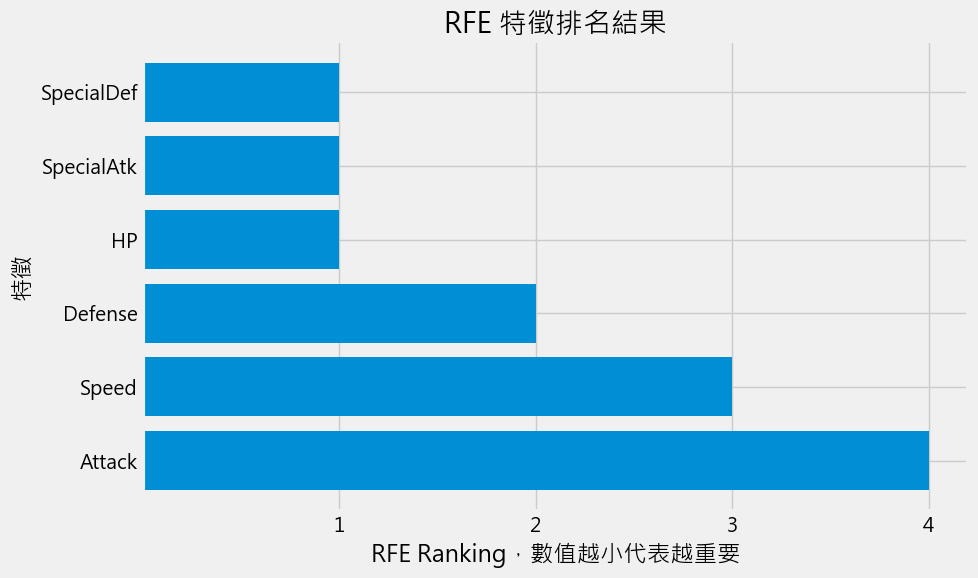

Permutation Feature Importance 結果：


,feature,importance_mean,importance_std
2,Defense,-0.007143,0.028272
5,Speed,-0.007143,0.010911
3,SpecialAtk,-0.009524,0.024281
1,Attack,-0.009524,0.011664
0,HP,-0.026190,0.019778
4,SpecialDef,-0.040476,0.010911


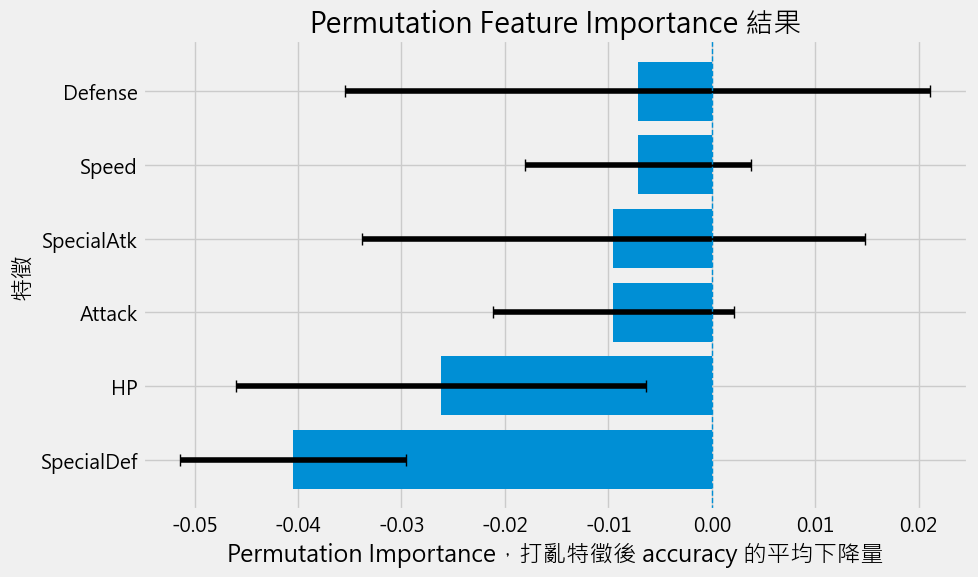

模型在測試資料上的 accuracy：
0.9285714285714286


In [11]:
# ============================================================
# 9. 選取重要特徵：RFE 與 Permutation Feature Importance
# ============================================================

import matplotlib.pyplot as plt

from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

trial_data = data.copy()

X = trial_data.loc[:, numeric_features].copy()
y = trial_data["Legendary"].astype(int).copy()

trial_imputer = SimpleImputer(strategy="median")
X_filled = trial_imputer.fit_transform(X)

trial_scaler = StandardScaler()
X_scaled = trial_scaler.fit_transform(X_filled)

# ------------------------------------------------------------
# RFE：遞迴特徵汰除
# ------------------------------------------------------------
# max_iter=1000 是為了確保 LogisticRegression 在訓練過程中能夠收斂，避免出現 ConvergenceWarning。
# 預設的 max_iter=100 可能不足以讓模型收斂，特別是當資料集較大或特徵較多時。
base_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0)
rfe_selector = RFE(estimator=base_model, n_features_to_select=3)
rfe_selector.fit(X_scaled, y)

rfe_table = pd.DataFrame()
rfe_table["feature"] = numeric_features
rfe_table["selected_by_RFE"] = rfe_selector.support_
rfe_table["RFE_ranking"] = rfe_selector.ranking_
rfe_table = rfe_table.sort_values("RFE_ranking")

print("RFE 選取結果：")
display(rfe_table)

# ------------------------------------------------------------
# RFE 視覺化
# ------------------------------------------------------------
# RFE_ranking 越小代表越重要。
# ranking = 1 代表最後被 RFE 選取的特徵。
rfe_plot_table = rfe_table.sort_values("RFE_ranking", ascending=False)

plt.figure(figsize=(10, 6))

plt.barh(
    rfe_plot_table["feature"],
    rfe_plot_table["RFE_ranking"]
)

plt.xlabel("RFE Ranking，數值越小代表越重要")
plt.ylabel("特徵")
plt.title("RFE 特徵排名結果")
plt.xticks(range(1, rfe_plot_table["RFE_ranking"].max() + 1))
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Permutation Feature Importance
# 先切分資料，再只用訓練資料 fit imputer、scaler、model
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

perm_imputer = SimpleImputer(strategy="median")
X_train_filled = perm_imputer.fit_transform(X_train)
X_test_filled = perm_imputer.transform(X_test)

perm_scaler = StandardScaler()
X_train_scaled = perm_scaler.fit_transform(X_train_filled)
X_test_scaled = perm_scaler.transform(X_test_filled)

perm_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=0)
perm_model.fit(X_train_scaled, y_train)

perm_result = permutation_importance(
    perm_model,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=0,
    scoring="accuracy"
)

perm_table = pd.DataFrame()
perm_table["feature"] = numeric_features
perm_table["importance_mean"] = perm_result.importances_mean
perm_table["importance_std"] = perm_result.importances_std
perm_table = perm_table.sort_values("importance_mean", ascending=False)

print("Permutation Feature Importance 結果：")
display(perm_table)

# ------------------------------------------------------------
# Permutation Feature Importance 視覺化
# ------------------------------------------------------------
# importance_mean 越大，代表打亂該特徵後，模型 accuracy 下降越多。
# 因此該特徵對模型越重要。
perm_plot_table = perm_table.sort_values("importance_mean", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    perm_plot_table["feature"],
    perm_plot_table["importance_mean"],
    xerr=perm_plot_table["importance_std"],
    capsize=4
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Permutation Importance，打亂特徵後 accuracy 的平均下降量")
plt.ylabel("特徵")
plt.title("Permutation Feature Importance 結果")
plt.tight_layout()
plt.show()

print("模型在測試資料上的 accuracy：")
print(perm_model.score(X_test_scaled, y_test))

Logistic Regression coefficient 結果：


,feature,coefficient,abs_coefficient
3,SpecialAtk,1.575317,1.575317
0,HP,1.267189,1.267189
4,SpecialDef,0.987341,0.987341
2,Defense,0.959910,0.959910
5,Speed,0.624050,0.624050
1,Attack,0.319023,0.319023


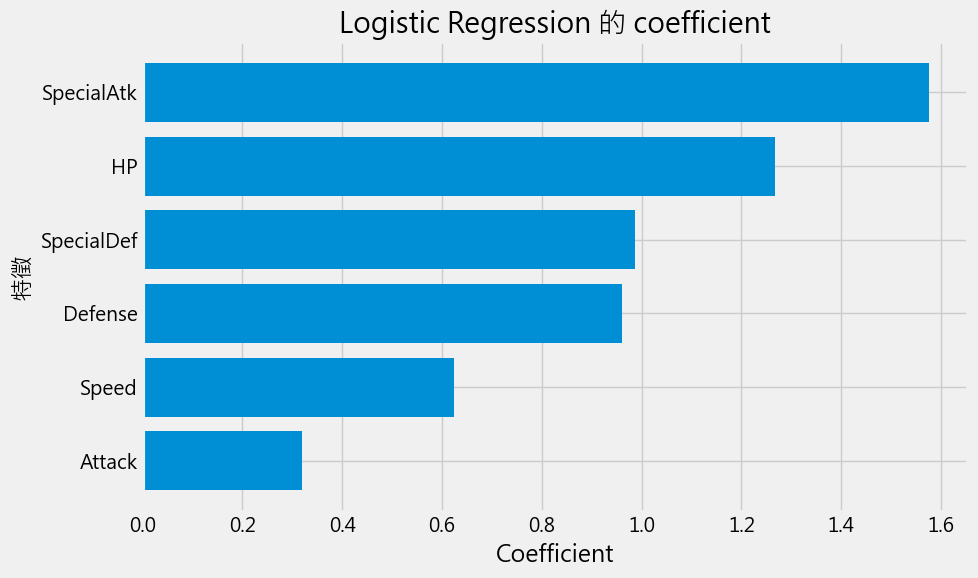

Random Forest feature_importances_ 結果：


,feature,feature_importance
0,HP,0.250221
3,SpecialAtk,0.231070
2,Defense,0.182640
4,SpecialDef,0.153753
1,Attack,0.110830
5,Speed,0.071486


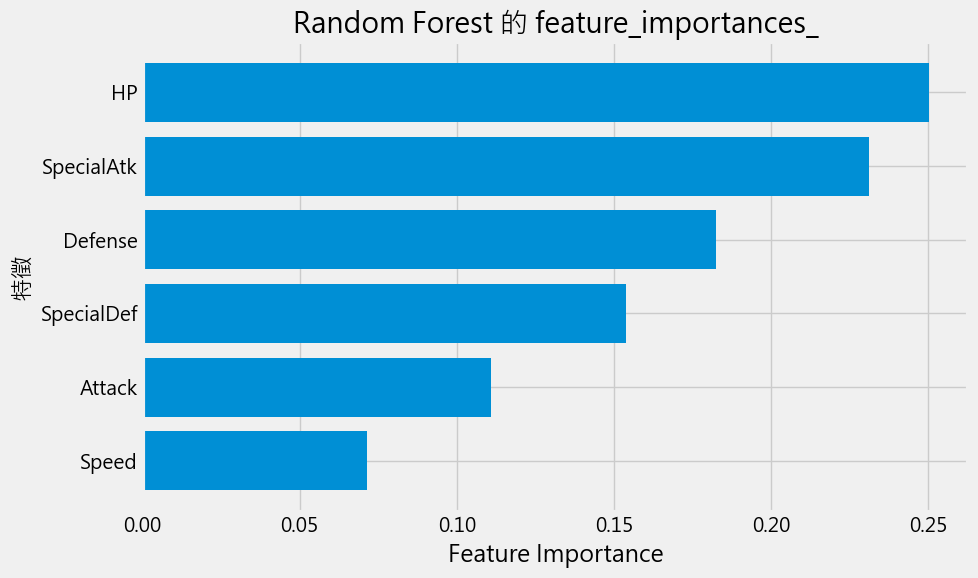

In [12]:
# ============================================================
# 9. 補充範例：coefficient 與 feature_importances_
# ============================================================

from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------------------------
# A. 線性模型：Logistic Regression 的 coef_
# ------------------------------------------------------------
# coef_ 是線性模型內部的係數。
# 在 Logistic Regression 中：
#   係數 > 0：特徵值越大，越傾向預測為 Legendary
#   係數 < 0：特徵值越大，越不傾向預測為 Legendary
#
# 注意：
# 因為 coef_ 會受到特徵尺度影響，
# 所以這裡使用前面已經標準化過的 X_train_scaled。
coef_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=0
)

coef_model.fit(X_train_scaled, y_train)

coef_table = pd.DataFrame()
coef_table["feature"] = numeric_features
coef_table["coefficient"] = coef_model.coef_[0]
coef_table["abs_coefficient"] = abs(coef_model.coef_[0])

coef_table = coef_table.sort_values(
    "abs_coefficient",
    ascending=False
)

print("Logistic Regression coefficient 結果：")
display(coef_table)

# ------------------------------------------------------------
# coefficient 視覺化
# ------------------------------------------------------------
# 這張圖保留正負方向。
# 正值代表越傾向 Legendary；
# 負值代表越不傾向 Legendary。
coef_plot_table = coef_table.sort_values("coefficient", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    coef_plot_table["feature"],
    coef_plot_table["coefficient"]
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Coefficient")
plt.ylabel("特徵")
plt.title("Logistic Regression 的 coefficient")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# B. 非線性模型：Random Forest 的 feature_importances_
# ------------------------------------------------------------
# feature_importances_ 是樹模型內部的特徵重要性。
# 數值越大，代表該特徵越常幫助模型做有效切分。
#
# 注意：
# feature_importances_ 通常只能看「重要程度」，
# 不能看正向或負向影響。
#
# Random Forest 不需要標準化，
# 所以這裡使用前面補值後的 X_train_filled。
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=0
)

rf_model.fit(X_train_filled, y_train)

rf_importance_table = pd.DataFrame()
rf_importance_table["feature"] = numeric_features
rf_importance_table["feature_importance"] = rf_model.feature_importances_

rf_importance_table = rf_importance_table.sort_values(
    "feature_importance",
    ascending=False
)

print("Random Forest feature_importances_ 結果：")
display(rf_importance_table)

# ------------------------------------------------------------
# feature_importances_ 視覺化
# ------------------------------------------------------------
rf_plot_table = rf_importance_table.sort_values(
    "feature_importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    rf_plot_table["feature"],
    rf_plot_table["feature_importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("特徵")
plt.title("Random Forest 的 feature_importances_")

plt.tight_layout()
plt.show()